# Laplace--Beltrami equation on the sphere

Quadrilateral-patch benchmark following the surface HPS framework of Fortunato (2024).


In [1]:
from pathlib import Path
import sys
import time

import numpy as np

project = Path.cwd().resolve()
if project.name == 'notebooks':
    project = project.parent
sys.path.insert(0, str(project))

import pysurfacefun as psf

output_dir = project / 'notebook_outputs'
output_dir.mkdir(exist_ok=True)


## Model problem

On the unit sphere,

$$\Delta_\Gamma Y_\ell^m = -\ell(\ell+1)Y_\ell^m.$$

The manufactured solution is $u=Y_{20}^{10}$ and the right-hand side is $f=-20\cdot21\,Y_{20}^{10}$.


In [2]:
l, m = 20, 10

def exact_solution(dom):
    return psf.surfacefun(
        lambda x, y, z: psf.real_spherical_harmonic(l, m, x, y, z),
        dom,
    )

dom = psf.sphere(n=15, nref=2)
u_exact = exact_solution(dom)
rhs = -l * (l + 1) * u_exact


In [3]:
L = psf.surfaceop(dom, {'lap': 1.0}, rhs)
L.rankdef = True

t0 = time.perf_counter()
u_h = L.solve().remove_mean()
elapsed = time.perf_counter() - t0

relerr = psf.norm(u_h - u_exact.remove_mean(), 'inf') / psf.norm(u_exact, 'inf')
print(f'relative L_inf error = {relerr:.3e}')
print(f'solve time           = {elapsed:.3f} s')


relative L_inf error = 4.595e-07
solve time           = 0.091 s


## p-refinement

The patch layout is fixed and the polynomial degree is increased.


In [4]:
n_values = [5,9,13,17,21]
rows = []

for n in n_values:
    dom_n = psf.sphere(n=n, nref=2)
    exact = exact_solution(dom_n)
    rhs_n = -l * (l + 1) * exact

    L_n = psf.surfaceop(dom_n, {'lap': 1.0}, rhs_n)
    L_n.rankdef = True

    t0 = time.perf_counter()
    sol = L_n.solve().remove_mean()
    solve_time = time.perf_counter() - t0

    err = psf.norm(sol - exact.remove_mean(), 'inf') / psf.norm(exact, 'inf')
    rows.append((n, n - 1, dom_n.npatches, err, solve_time))
    print(f'n = {n:2d}, p = {n-1:2d}, patches = {dom_n.npatches:3d}, rel error = {err:.3e}, time = {solve_time:.3f} s')


n =  5, p =  4, patches =  96, rel error = 1.955e+00, time = 0.045 s
n =  9, p =  8, patches =  96, rel error = 1.743e-02, time = 0.063 s
n = 13, p = 12, patches =  96, rel error = 1.650e-05, time = 0.077 s
n = 17, p = 16, patches =  96, rel error = 1.027e-08, time = 0.107 s
n = 21, p = 20, patches =  96, rel error = 1.021e-13, time = 0.151 s


## Output


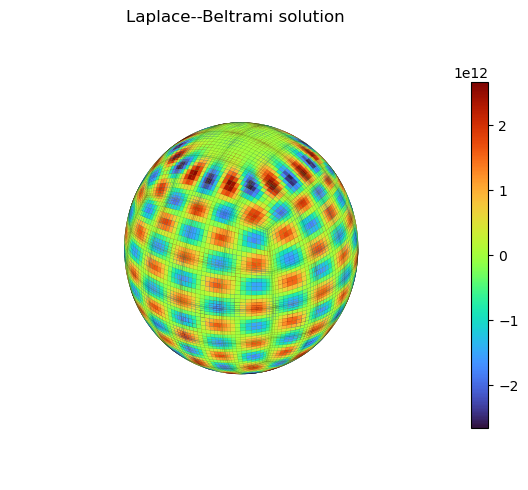

In [7]:
try:
    psf.plot_surface(u_h, title='Laplace--Beltrami solution')
except Exception as exc:
    print('surface plot skipped:', exc)


## Reference

D. Fortunato, *A high-order fast direct solver for surface PDEs*, SIAM Journal on Scientific Computing, 46(4), A2582--A2606, 2024.
